                Q          J_1s          J_2s          J_2p       J_total
0    0.000000e+00  1.520764e-01  1.357302e+01  4.797532e-01  2.840971e+01
1    5.000000e-02  1.205050e-01  9.438722e+00  4.797057e-01  2.007787e+01
2    1.000000e-01  9.683664e-02  6.361850e+00  4.794983e-01  1.387637e+01
3    1.500000e-01  8.371006e-02  4.704521e+00  4.787285e-01  1.053392e+01
4    2.000000e-01  7.454495e-02  3.596582e+00  4.768552e-01  8.295964e+00
5    2.500000e-01  6.749863e-02  2.792254e+00  4.732853e-01  6.666076e+00
6    3.000000e-01  6.178126e-02  2.184191e+00  4.674854e-01  5.426915e+00
7    3.500000e-01  5.697894e-02  1.714378e+00  4.590717e-01  4.460857e+00
8    4.000000e-01  5.284696e-02  1.347029e+00  4.478626e-01  3.695477e+00
9    4.500000e-01  4.922833e-02  1.058000e+00  4.338907e-01  3.082237e+00
10   5.000000e-01  4.601617e-02  8.299553e-01  4.173806e-01  2.586704e+00
11   5.500000e-01  4.313435e-02  6.499097e-01  3.987044e-01  2.183497e+00
12   6.000000e-01  4.052670e-02  5.078

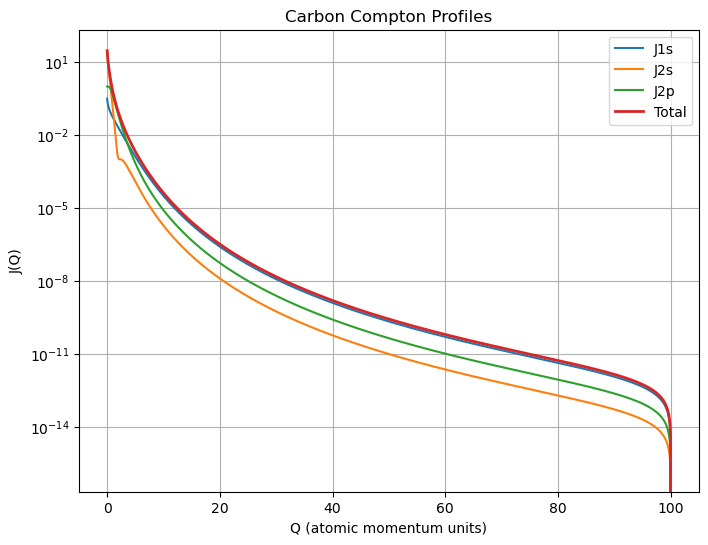

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

# =========================
# p or Q grid
# =========================
p = np.arange(0.0, 100.0 + 0.05, 0.05)

# Avoid p=0 problem in I(p)/p
p_safe = p.copy()
p_safe[0] = 1e-12

# =========================
# I_1s(p)
# =========================
def I_1s(p):
    F = (
        17.4697 * 16.9872 / ((8.4936**2 + p**2)**2)
        + 10.2078 * 9.7576 / ((4.8788**2 + p**2)**2)
        - 7.3550 * (2**4) * 15.4660 * (15.4660**2 - p**2) / ((15.4660**2 + p**2)**4)
        + 32.1360 * 2 * (3*(7.0500**2) - p**2) / ((7.0500**2 + p**2)**3)
        + 0.00789 * 2 * (3*(2.2640**2) - p**2) / ((2.2640**2 + p**2)**3)
        + 0.00142 * 2 * (3*(1.4747**2) - p**2) / ((1.4747**2 + p**2)**3)
        + 0.000201 * 2 * (3*(1.1639**2) - p**2) / ((1.1639**2 + p**2)**3)
    )
    return (2/np.pi) * F**2


# =========================
# I_2s(p)
# =========================
def I_2s(p):
    F = (
        -3.5510 * 16.9872 / ((8.4936**2 + p**2)**2)
        + 9.4467 * 9.7576 / ((4.8788**2 + p**2)**2)
        - 2.3494 * (2**4) * 15.4660 * (15.4660**2 - p**2) / ((15.4660**2 + p**2)**4)
        - 13.8966 * 2 * (3*(7.0500**2) - p**2) / ((7.0500**2 + p**2)**3)
        - 3.5008 * 2 * (3*(2.2640**2) - p**2) / ((2.2640**2 + p**2)**3)
        - 1.7660 * 2 * (3*(1.4747**2) - p**2) / ((1.4747**2 + p**2)**3)
        - 0.2127 * 2 * (3*(1.1639**2) - p**2) / ((1.1639**2 + p**2)**3)
    )
    return (2/np.pi) * F**2


# =========================
# I_2p(p)
# =========================
def I_2p(p):
    F = (
        59.9645 / ((7.0500**2 + p**2)**3)
        + 39.5459 / ((3.2275**2 + p**2)**3)
        + 33.1827 / ((2.1908**2 + p**2)**3)
        + 13.6785 / ((1.4413**2 + p**2)**3)
        + 3.52243 / ((1.0242**2 + p**2)**3)
    )
    return (2/np.pi) * p**4 * F**2


# =========================
# Calculate I(p)
# =========================
I1s = I_1s(p_safe)
I2s = I_2s(p_safe)
I2p = I_2p(p_safe)

# =========================
# Calculate J(Q)
# J(Q) = 1/2 ∫_Q^∞ I(p)/p dp
# Numerically integrate from high p down to Q
# =========================
def compute_J_from_I(I_values, p_grid):
    integrand = I_values / p_grid
    integrand[0] = integrand[1]   # avoid p=0 singular display issue

    # reverse cumulative integral
    rev_int = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J = -0.5 * rev_int[::-1]
    return J

J1s = compute_J_from_I(I1s, p_safe)
J2s = compute_J_from_I(I2s, p_safe)
J2p = compute_J_from_I(I2p, p_safe)

J_total = 2*J1s + 2*J2s + 2*J2p

# =========================
# Table
# =========================
table = pd.DataFrame({
    "Q": p,
    "J_1s": J1s,
    "J_2s": J2s,
    "J_2p": J2p,
    "J_total": J_total
})

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("carbon_J_profiles.csv", index=False)

# =========================
# Plot J(Q)
# =========================
plt.figure(figsize=(8,6))

plt.plot(p, 2*J1s, label="J1s")
plt.plot(p, 2*J2s, label="J2s")
plt.plot(p, 2*J2p, label="J2p")
plt.plot(p, J_total, label="Total", linewidth=2)

plt.xlabel("Q (atomic momentum units)")
plt.ylabel("J(Q)")
plt.title("Carbon Compton Profiles")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()